# Proyecto 10 - DQN con Stable-Baselines3

Entrenamiento de un agente DQN para `SpaceInvaders-v0` usando Stable-Baselines3.

El notebook mantiene la idea de la práctica anterior:

- imágenes de entrada de 84x84,
- pila de 4 frames,
- red convolucional tipo DQN Atari,
- recompensa clipped,
- conteo de episodios consecutivos con recompensa clipped superior a 20,
- guardado de pesos `latest`, `best_consecutive` y `best_avg50`.


In [1]:
# ============================
# 1. Instalación de librerías
# ============================

# Instalación completa para usar SpaceInvaders-v0 con Gym clásico

%pip install gym==0.17.3
%pip install git+https://github.com/Kojoley/atari-py.git
%pip install stable-baselines3==0.10.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 77.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 77.5 MB/s eta 0:00:00
  Created wheel for gym: filename=gym-0.17.3-py3-none-any.whl size=1654617 sha256=556f40beb1af94ee3f9cd5bca9b1784f93c1953a46b019714316f1f0b7ecb52c
  Stored in directory: /root/.cache/pip/wheels/99/7e/03/69cdeb432380e05bc9a56ff68451d8063e41aa06db508f4be5
Successfully built gym
  Attempting uninstall: cloudpickle
    Found existing installation: cloudpickle 3.1.2
    Uninstalling cloudpickle-3.1.2:
      Successfully uninstalled cloudpickle-3.1.2
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2026.1.1 requires cloudp

In [2]:
import gym
from stable_baselines3 import DQN

ENV_ID = "SpaceInvaders-v0"
env = gym.make(ENV_ID)

print("Gym OK")
print("SB3 DQN OK")

Gym OK
SB3 DQN OK


In [3]:
# ============================
# 2. Imports
# ============================

from pathlib import Path
import json
import time
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import gym
import torch as th
import torch.nn as nn

from google.colab import drive

from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_atari_env
from stable_baselines3.common.vec_env import VecFrameStack
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor


In [5]:
# ============================
# 3. Google Drive y rutas
# ============================

drive.mount('/content/gdrive')

drive_root = '/content/gdrive/My Drive/08_MIAR/sb3'
PROJECT_NAME = 'sb3_spaceinvaders_v0_1'

OUTPUT_DIR = Path(drive_root) / 'datos' / PROJECT_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Modelo completo de SB3. SB3 también escribirá sus logs en TensorBoard.
MODEL_LATEST = OUTPUT_DIR / 'dqn_spaceinvaders_v0_sb3_latest.zip'

# Fichero auxiliar solo por si el guardado completo de SB3 falla en Colab.
POLICY_LATEST = OUTPUT_DIR / 'dqn_spaceinvaders_v0_policy_latest.pt'

TENSORBOARD_DIR = OUTPUT_DIR / 'tensorboard'

print('OUTPUT_DIR:', OUTPUT_DIR)
print('MODEL_LATEST:', MODEL_LATEST)
print('POLICY_LATEST:', POLICY_LATEST)
print('TENSORBOARD_DIR:', TENSORBOARD_DIR)


Mounted at /content/gdrive
OUTPUT_DIR: /content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1
MODEL_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1/dqn_spaceinvaders_v0_sb3_latest.zip
POLICY_LATEST: /content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1/dqn_spaceinvaders_v0_policy_latest.pt
TENSORBOARD_DIR: /content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1/tensorboard


In [24]:
# ============================
# 4. Parámetros principales
# ============================

ENV_ID = 'SpaceInvaders-v0'
SEED = 42

TOTAL_TIMESTEPS = 10_000_000

LEARNING_RATE = 1e-4
BUFFER_SIZE = 100_000
LEARNING_STARTS = 50_000
BATCH_SIZE = 32
GAMMA = 0.99
TRAIN_FREQ = 4
TARGET_UPDATE_INTERVAL = 10_000

EXPLORATION_INITIAL_EPS = 1.0
EXPLORATION_FINAL_EPS = 0.001
EXPLORATION_FRACTION = 0.30

CONSECUTIVE_THRESHOLD = 20.0
TARGET_CONSECUTIVE_EPISODES = 100

SAVE_FREQ_STEPS = 100_000
PRINT_EVERY_EPISODES = 10

LOAD_MODEL = False


In [27]:
# ============================
# 5. Comprobación del entorno
# ============================
# Si SpaceInvaders-v0 no existe en el entorno de Colab, esta celda dará error.

test_env = gym.make(ENV_ID)
print('Entorno creado correctamente:', ENV_ID)
print('Action space:', test_env.action_space)
print('Observation space:', test_env.observation_space)
test_env.close()


Entorno creado correctamente: SpaceInvaders-v0
Action space: Discrete(6)
Observation space: Box(0, 255, (210, 160, 3), uint8)


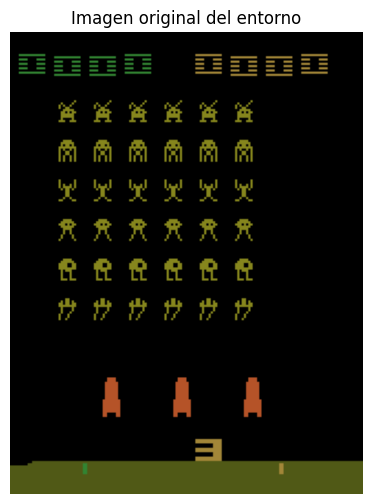

In [28]:
# ============================
# 6. Mostrar imagen original del entorno
# ============================

def reset_env_compat(env):
    result = env.reset()
    if isinstance(result, tuple):
        return result[0]
    return result

raw_env = gym.make(ENV_ID)
obs = reset_env_compat(raw_env)

try:
    frame_rgb = raw_env.render(mode='rgb_array')
except TypeError:
    frame_rgb = raw_env.render()

plt.figure(figsize=(6, 6))
plt.imshow(frame_rgb)
plt.title('Imagen original del entorno')
plt.axis('off')
plt.show()

raw_env.close()


In [29]:
# ============================
# 7. Crear entorno vectorizado para SB3
# ============================
# make_atari_env aplica los wrappers habituales de Atari.
# clip_reward=True hace que la recompensa sea clipped [-1, 0, 1].
# VecFrameStack apila 4 imágenes consecutivas.

def create_env():
    env = make_atari_env(
        ENV_ID,
        n_envs=1,
        seed=SEED,
        monitor_dir=str(OUTPUT_DIR / 'monitor'),
        wrapper_kwargs=dict(clip_reward=True)
    )
    env = VecFrameStack(env, n_stack=4)
    return env

env = create_env()
print('Observation space SB3:', env.observation_space)
print('Action space SB3:', env.action_space)

Observation space SB3: Box(0, 255, (84, 84, 4), uint8)
Action space SB3: Discrete(6)


Shape observación: (1, 84, 84, 4)


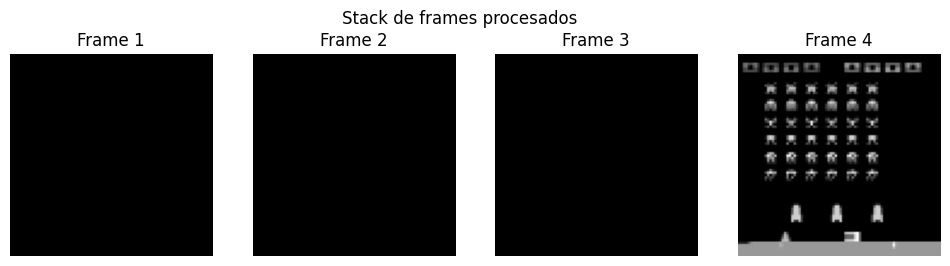

In [30]:
# ============================
# 8. Mostrar imágenes procesadas 84x84 y stack de frames
# ============================

obs = env.reset()
print('Shape observación:', obs.shape)

# Normalmente con CnnPolicy/SB3 queda en formato: (n_envs, channels, height, width)
obs0 = obs[0]

if obs0.shape[0] in [1, 3, 4, 12]:
    # channels first
    frames = obs0
else:
    # channels last
    frames = np.transpose(obs0, (2, 0, 1))

num_frames = min(4, frames.shape[0])

plt.figure(figsize=(12, 3))
for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    plt.imshow(frames[i], cmap='gray')
    plt.title(f'Frame {i + 1}')
    plt.axis('off')
plt.suptitle('Stack de frames procesados')
plt.show()


In [31]:
# ============================
# 9. Red convolucional personalizada 84x84
# ============================
# Arquitectura tipo DQN Atari:
# Entrada: 4 x 84 x 84
# Conv2D 32 filtros 8x8 stride 4
# Conv2D 64 filtros 4x4 stride 2
# Conv2D 64 filtros 3x3 stride 1
# Capa densa de 512 características

class CustomCNN84(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=512):
        super().__init__(observation_space, features_dim)

        n_input_channels = observation_space.shape[0]

        self.cnn = nn.Sequential(
            nn.Conv2d(n_input_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten()
        )

        with th.no_grad():
            sample = th.as_tensor(observation_space.sample()[None]).float()
            n_flatten = self.cnn(sample).shape[1]

        self.linear = nn.Sequential(
            nn.Linear(n_flatten, features_dim),
            nn.ReLU()
        )

    def forward(self, observations):
        return self.linear(self.cnn(observations))

policy_kwargs = dict(
    features_extractor_class=CustomCNN84,
    features_extractor_kwargs=dict(features_dim=512),
    net_arch=[]
)


In [32]:
# ============================
# 9. Función auxiliar de guardado
# ============================
# Esta función solo se usa como alternativa si model.save(...) falla por problemas
# de serialización en Colab/Python. El logger oficial será el de SB3/TensorBoard.

def save_policy_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    th.save(
        {
            "policy_state_dict": model.policy.state_dict(),
            "optimizer_state_dict": model.policy.optimizer.state_dict(),
            "num_timesteps": model.num_timesteps,
            "exploration_rate": getattr(model, "exploration_rate", None),
        },
        path
    )


In [33]:
# ============================
# 10. Callback personalizado solo para imprimir métricas del objetivo
# ============================
# SB3 se encarga de escribir sus logs en TensorBoard.
# Este callback no escribe JSON ni guarda modelos: solo imprime consec, max_consec y avg_clip50.

class ConsecutiveRewardCallback(BaseCallback):
    def __init__(self, verbose=1):
        super().__init__(verbose)
        self.episode = 0
        self.consecutive = 0
        self.max_consecutive = 0
        self.recent_clipped_rewards = deque(maxlen=50)
        self.start_time = time.time()

    def _on_step(self) -> bool:
        infos = self.locals.get('infos', [])

        for info in infos:
            if 'episode' not in info:
                continue

            ep_reward = float(info['episode']['r'])

            # IMPORTANTE:
            # Esto es correcto si el entorno ya está usando recompensa clipped.
            # Si no hay wrapper de ClipReward, ep_reward sería recompensa real.
            clipped_reward = ep_reward/10

            self.recent_clipped_rewards.append(clipped_reward)

            if clipped_reward > CONSECUTIVE_THRESHOLD:
                self.consecutive += 1
            else:
                self.consecutive = 0

            if self.consecutive > self.max_consecutive:
                self.max_consecutive = self.consecutive

            avg_clip50 = (
                float(np.mean(self.recent_clipped_rewards))
                if len(self.recent_clipped_rewards) > 0
                else 0.0
            )

            if self.episode % PRINT_EVERY_EPISODES == 0:
                print(
                    f'EP={self.episode:,} | '
                    f'STEP={self.num_timesteps:,} | '
                    f'clip={clipped_reward:.0f} | '
                    f'consec={self.consecutive} | '
                    f'max_consec={self.max_consecutive} | '
                    f'avg_clip50={avg_clip50:.2f}'
                )

            self.episode += 1

            if self.max_consecutive >= TARGET_CONSECUTIVE_EPISODES:
                print('Objetivo conseguido: 100 episodios consecutivos superando el umbral.')
                return False

        return True

    def _on_training_end(self):
        print('Entrenamiento finalizado.')
        print('max_consec alcanzado:', self.max_consecutive)


In [34]:
# ============================
# 11. Crear o cargar modelo DQN
# ============================

if LOAD_MODEL and MODEL_LATEST.exists():
    print("Cargando modelo desde:", MODEL_LATEST)

    model = DQN.load(
        str(MODEL_LATEST),
        env=env,
        device="auto",
        tensorboard_log=str(TENSORBOARD_DIR)
    )

    print("Modelo cargado correctamente.")

else:
    print("Creando modelo nuevo.")

    model = DQN(
        policy="CnnPolicy",
        env=env,
        learning_rate=LEARNING_RATE,
        buffer_size=BUFFER_SIZE,
        learning_starts=LEARNING_STARTS,
        batch_size=BATCH_SIZE,
        gamma=GAMMA,
        train_freq=TRAIN_FREQ,
        target_update_interval=TARGET_UPDATE_INTERVAL,
        exploration_initial_eps=EXPLORATION_INITIAL_EPS,
        exploration_final_eps=EXPLORATION_FINAL_EPS,
        exploration_fraction=EXPLORATION_FRACTION,
        policy_kwargs=policy_kwargs,
        tensorboard_log=str(TENSORBOARD_DIR),
        verbose=1,
        seed=SEED,
        device="auto"
    )

    print("Modelo nuevo creado correctamente.")

print("Política usada:")
print(model.policy)


Creando modelo nuevo.
Using cuda device
Wrapping the env in a VecTransposeImage.
Modelo nuevo creado correctamente.
Política usada:
CnnPolicy(
  (q_net): QNetwork(
    (features_extractor): CustomCNN84(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
        (3): ReLU()
        (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
        (5): ReLU()
        (6): Flatten(start_dim=1, end_dim=-1)
      )
      (linear): Sequential(
        (0): Linear(in_features=3136, out_features=512, bias=True)
        (1): ReLU()
      )
    )
    (q_net): Sequential(
      (0): Linear(in_features=512, out_features=6, bias=True)
    )
  )
  (q_net_target): QNetwork(
    (features_extractor): CustomCNN84(
      (cnn): Sequential(
        (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
        (1): ReLU()
        (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
       

In [35]:
# ============================
# 12. Entrenamiento
# ============================

callback = ConsecutiveRewardCallback(verbose=0)

model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=callback,
    reset_num_timesteps=not LOAD_MODEL,
    tb_log_name="DQN_SpaceInvaders_v0",
    log_interval=100
)


Se han truncado las últimas 5000 líneas del flujo de salida.
EP=2,620 | STEP=428,723 | clip=16 | consec=0 | max_consec=6 | avg_clip50=18.63
EP=2,630 | STEP=430,686 | clip=19 | consec=0 | max_consec=6 | avg_clip50=17.88
EP=2,640 | STEP=432,429 | clip=74 | consec=1 | max_consec=6 | avg_clip50=17.67
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 802      |
|    ep_rew_mean      | 196      |
|    exploration rate | 0.856    |
| time/               |          |
|    episodes         | 7900     |
|    fps              | 273      |
|    time_elapsed     | 1582     |
|    total timesteps  | 432641   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0965   |
|    n_updates        | 95660    |
----------------------------------
EP=2,650 | STEP=434,058 | clip=10 | consec=0 | max_consec=6 | avg_clip50=16.23
EP=2,660 | STEP=436,294 | clip=22 | consec=4 | max_consec=6 | avg_clip50=19.18
EP=2,670 | STEP=438

In [36]:
# ============================
# 13. Guardado manual del modelo
# ============================
# Primero se intenta guardar con SB3. Si falla por serialización en Colab,
# se guarda únicamente la política y el optimizador con PyTorch.

try:
    model.save(str(MODEL_LATEST))
    print('Modelo completo SB3 guardado en:', MODEL_LATEST)

except Exception as e:
    print('No se pudo guardar el modelo completo con SB3.')
    print('Error:', repr(e))
    save_policy_checkpoint(model, POLICY_LATEST)
    print('Política/optimizador guardados con PyTorch en:', POLICY_LATEST)


No se pudo guardar el modelo completo con SB3.
Error: IndexError('tuple index out of range')
Política/optimizador guardados con PyTorch en: /content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1/dqn_spaceinvaders_v0_policy_latest.pt


In [37]:
# ============================
# 14. Gráficas del entrenamiento
# ============================

with open(LOG_FILENAME, 'r') as f:
    data = json.load(f)

steps = np.array(data['total_steps'])
clipped = np.array(data['clipped_episode_reward'])
consec = np.array(data['consecutive_clipped_over_20'])
max_consec = np.array(data['max_consecutive_clipped_over_20'])
avg50 = np.array(data['avg_clip50'])

plt.figure(figsize=(10, 4))
plt.plot(steps, clipped)
plt.title('Recompensa clipped por episodio')
plt.xlabel('Steps')
plt.ylabel('Clipped reward')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(steps, avg50)
plt.title('Media de recompensa clipped en los últimos 50 episodios')
plt.xlabel('Steps')
plt.ylabel('avg_clip50')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(steps, consec, label='consec')
plt.plot(steps, max_consec, label='max_consec')
plt.axhline(TARGET_CONSECUTIVE_EPISODES, linestyle='--')
plt.title('Episodios consecutivos con recompensa clipped > 20')
plt.xlabel('Steps')
plt.ylabel('Consecutivos')
plt.legend()
plt.grid(True)
plt.show()

print('Mejor max_consec:', int(max(max_consec)) if len(max_consec) else 0)
print('Mejor avg_clip50:', float(max(avg50)) if len(avg50) else 0.0)


NameError: name 'LOG_FILENAME' is not defined

No se pudo cargar MODEL_LATEST. Se usa el modelo actual en memoria.
Error: ValueError("Error: the file <_io.BufferedReader name='/content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1/dqn_spaceinvaders_v0_sb3_latest.zip'> wasn't a zip-file")


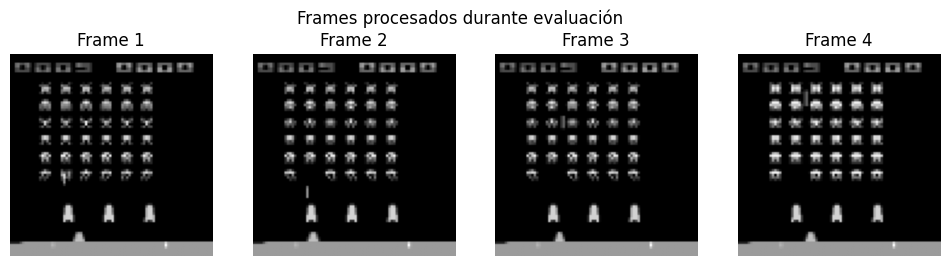

In [38]:
# ============================
# 15. Evaluación visual rápida
# ============================
# Si existe el modelo completo de SB3, se carga.
# Si no, se usa el modelo actual de memoria.

if MODEL_LATEST.exists():
    try:
        model = DQN.load(str(MODEL_LATEST), env=env, device='auto')
        print('Modelo cargado para evaluación:', MODEL_LATEST)
    except Exception as e:
        print('No se pudo cargar MODEL_LATEST. Se usa el modelo actual en memoria.')
        print('Error:', repr(e))
else:
    print('No existe MODEL_LATEST. Se usa el modelo actual en memoria.')

obs = env.reset()
for _ in range(10):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = env.step(action)

obs0 = obs[0]
if obs0.shape[0] in [1, 3, 4, 12]:
    frames = obs0
else:
    frames = np.transpose(obs0, (2, 0, 1))

num_frames = min(4, frames.shape[0])
plt.figure(figsize=(12, 3))
for i in range(num_frames):
    plt.subplot(1, num_frames, i + 1)
    plt.imshow(frames[i], cmap='gray')
    plt.title(f'Frame {i + 1}')
    plt.axis('off')
plt.suptitle('Frames procesados durante evaluación')
plt.show()


In [39]:
# ============================
# 16. Cerrar entorno
# ============================

env.close()


In [41]:
from pathlib import Path

OUTPUT_DIR = Path("/content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1")
LOG_FILENAME = OUTPUT_DIR / "dqn_SpaceInvaders-v0_sb3_log.json"

print(LOG_FILENAME)
print(LOG_FILENAME.exists())

/content/gdrive/My Drive/08_MIAR/sb3/datos/sb3_spaceinvaders_v0_1/dqn_SpaceInvaders-v0_sb3_log.json
False
